# Notebook 03 — Prétraitement des données et critères métier

## Objectif

Ce notebook prépare le jeu de données issu de l'audit qualité pour les étapes de **Feature Engineering** et de détection.

Deux niveaux de traitement sont distingués :

1. **Prétraitement technique** : homogénéisation des formats, conversion des types et contrôle de la structure ;
2. **Critères d'exploitabilité métier** : conservation uniquement des observations disposant d'au moins une marge en année N et d'un identifiant EAN.

Les situations économiquement atypiques (prix négatifs, prix de vente inférieur au prix d'achat, marges hors plage, etc.) **ne sont pas supprimées à ce stade**. Elles doivent rester disponibles pour les mécanismes de détection décrits dans les notebooks suivants.

Le résultat principal est `dataset_business.csv`.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 120

In [3]:
# Chemins du projet

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = DATA_DIR / "results"
PREPROCESSING_DIR = RESULTS_DIR / "preprocessing"

PREPROCESSING_DIR.mkdir(parents=True, exist_ok=True)

DATASET_RAW = PROCESSED_DIR / "dataset_raw.csv"
DATASET_BUSINESS = PROCESSED_DIR / "dataset_business.csv"


In [4]:
# Chargement

if not DATASET_RAW.exists():
    raise FileNotFoundError(
        f"Le fichier source est introuvable : {DATASET_RAW}"
    )

df = pd.read_csv(DATASET_RAW)

print(f"Observations : {len(df):,}")
print(f"Variables    : {df.shape[1]}")
display(df.head(5))

Observations : 74,888
Variables    : 15


,Year,MonthLib,International Department,International Sub Department,International Family,EAN,Tx M3N MDH Inter N,Tx M3N non CP N,Tx M3N MDH Inter N-1,Tx M3N non CP N-1,Average Purchasing Price N,Average selling price N,Average Purchasing Price N-1,Average Selling Price N-1,Source_File
0,2025,January,13-Lighting,02-Electric Bulbs,"631-Halogen, Incandescent And Compact Fluoresc...",3.276007e+12,"76,1 %",NaN,NaN,NaN,1.561697,6.521332,NaN,NaN,electric_bulbs_2025_LMFR
1,2025,January,13-Lighting,02-Electric Bulbs,"631-Halogen, Incandescent And Compact Fluoresc...",3.276007e+12,"80,9 %",NaN,NaN,NaN,1.549626,8.114869,NaN,NaN,electric_bulbs_2025_LMFR
2,2025,January,13-Lighting,02-Electric Bulbs,"631-Halogen, Incandescent And Compact Fluoresc...",3.276007e+12,"82,2 %",NaN,NaN,NaN,0.580000,3.255032,NaN,NaN,electric_bulbs_2025_LMFR
3,2025,January,13-Lighting,02-Electric Bulbs,"631-Halogen, Incandescent And Compact Fluoresc...",3.276007e+12,"80,1 %",NaN,NaN,NaN,0.580000,2.917075,NaN,NaN,electric_bulbs_2025_LMFR
4,2025,January,13-Lighting,02-Electric Bulbs,"631-Halogen, Incandescent And Compact Fluoresc...",3.276007e+12,"84,4 %",NaN,NaN,NaN,0.380000,2.439489,NaN,NaN,electric_bulbs_2025_LMFR


## 1. Contrôle du schéma d'entrée

Le schéma attendu est vérifié avant toute transformation afin d'éviter qu'une modification de la structure du dataset source ne passe inaperçue.

In [5]:
expected_columns = [
    "Year",
    "MonthLib",
    "International Department",
    "International Sub Department",
    "International Family",
    "EAN",
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N",
    "Tx M3N MDH Inter N-1",
    "Tx M3N non CP N-1",
    "Average Purchasing Price N",
    "Average selling price N",
    "Average Purchasing Price N-1",
    "Average Selling Price N-1",
    "Source_File",
]

missing_columns = [c for c in expected_columns if c not in df.columns]
extra_columns = [c for c in df.columns if c not in expected_columns]

if missing_columns:
    raise ValueError(f"Colonnes attendues absentes : {missing_columns}")

print("Schéma attendu : OK")
if extra_columns:
    print(f"Colonnes supplémentaires conservées : {extra_columns}")

Schéma attendu : OK


## 2. Prétraitement technique

Les transformations portent sur les formats et non sur la détection d'anomalies. Aucune observation n'est supprimée pour la seule raison qu'une valeur économique est atypique.

In [6]:
df_preprocessed = df[expected_columns].copy()

# Variables textuelles : suppression des espaces superflus
text_columns = df_preprocessed.select_dtypes(
    include=["object", "string"]
).columns.tolist()

for col in text_columns:
    df_preprocessed[col] = (
        df_preprocessed[col]
        .astype("string")
        .str.strip()
    )

# EAN : identifiant conservé comme chaîne
df_preprocessed["EAN"] = (
    df_preprocessed["EAN"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
    .replace("", pd.NA)
)

print(f"Variables textuelles nettoyées : {len(text_columns)}")
print(f"EAN manquants : {df_preprocessed['EAN'].isna().sum():,}")

Variables textuelles nettoyées : 9
EAN manquants : 164


In [8]:
# Conversion des taux de marge 
margin_columns = [
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N",
    "Tx M3N MDH Inter N-1",
    "Tx M3N non CP N-1",
]

for col in margin_columns:
    df_preprocessed[col] = (
        df_preprocessed[col]
        .astype("string")
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_preprocessed[col] = pd.to_numeric(
        df_preprocessed[col],
        errors="coerce"
    )

# Conversion des prix
price_columns = [
    "Average Purchasing Price N",
    "Average selling price N",
    "Average Purchasing Price N-1",
    "Average Selling Price N-1",
]

for col in price_columns:
    df_preprocessed[col] = pd.to_numeric(
        df_preprocessed[col],
        errors="coerce"
    )

# Année
df_preprocessed["Year"] = pd.to_numeric(
    df_preprocessed["Year"],
    errors="coerce"
).astype("Int64")

print("Conversions numériques terminées.")

Conversions numériques terminées.


In [9]:
# Validation de MonthLib 

month_order = {
    "January": 1, "February": 2, "March": 3, "April": 4,
    "May": 5, "June": 6, "July": 7, "August": 8,
    "September": 9, "October": 10, "November": 11, "December": 12
}

month_number = (
    df_preprocessed["MonthLib"]
    .astype("string")
    .str.strip()
    .map(month_order)
)

unknown_months = sorted(
    df_preprocessed.loc[month_number.isna(), "MonthLib"]
    .dropna()
    .unique()
    .tolist()
)

if unknown_months:
    raise ValueError(
        f"Valeurs MonthLib non reconnues : {unknown_months}"
    )

print("MonthLib : 12 mois attendus reconnus.")

MonthLib : 12 mois attendus reconnus.


In [10]:
# Contrôle des types et des valeurs manquantes après prétraitement

type_summary = pd.DataFrame({
    "Variable": df_preprocessed.columns,
    "Type": df_preprocessed.dtypes.astype(str).values,
    "Valeurs_manquantes": df_preprocessed.isna().sum().values,
})

display(type_summary)

,Variable,Type,Valeurs_manquantes
0,Year,Int64,0
1,MonthLib,string,0
2,International Department,string,0
3,International Sub Department,string,0
4,International Family,string,0
5,EAN,string,164
6,Tx M3N MDH Inter N,Float64,59413
7,Tx M3N non CP N,Float64,21895
8,Tx M3N MDH Inter N-1,Float64,68676
9,Tx M3N non CP N-1,Float64,54640


## 3. Critères d'exploitabilité métier

Les filtres appliqués ici ne correspondent pas aux règles d'anomalie économique.

Ils servent uniquement à définir une **population d'étude exploitable** :

- au moins une des deux mesures de marge de l'année N doit être disponible ;
- chaque observation retenue doit être rattachable à un EAN.

Les valeurs atypiques des prix et des marges sont conservées.

In [11]:
df_business = df_preprocessed.copy()

population_initiale = len(df_business)

# Critère 1 : au moins une marge disponible en année N
has_margin_n = (
    df_business["Tx M3N MDH Inter N"].notna()
    | df_business["Tx M3N non CP N"].notna()
)

nb_avant_marge = len(df_business)
df_business = df_business.loc[has_margin_n].copy()
exclus_sans_marge = nb_avant_marge - len(df_business)

# Critère 2 : EAN disponible
has_ean = df_business["EAN"].notna()

nb_avant_ean = len(df_business)
df_business = df_business.loc[has_ean].copy()
exclus_sans_ean = nb_avant_ean - len(df_business)

print(f"Population initiale          : {population_initiale:,}")
print(f"Exclus — aucune marge N      : {exclus_sans_marge:,}")
print(f"Exclus — EAN manquant        : {exclus_sans_ean:,}")
print(f"Population retenue           : {len(df_business):,}")

Population initiale          : 74,888
Exclus — aucune marge N      : 6,420
Exclus — EAN manquant        : 144
Population retenue           : 68,324


In [12]:
# Vérification des critères après filtrage
assert (
    df_business["Tx M3N MDH Inter N"].notna()
    | df_business["Tx M3N non CP N"].notna()
).all()

assert df_business["EAN"].notna().all()

print("Contrôles des critères métier : OK")

Contrôles des critères métier : OK


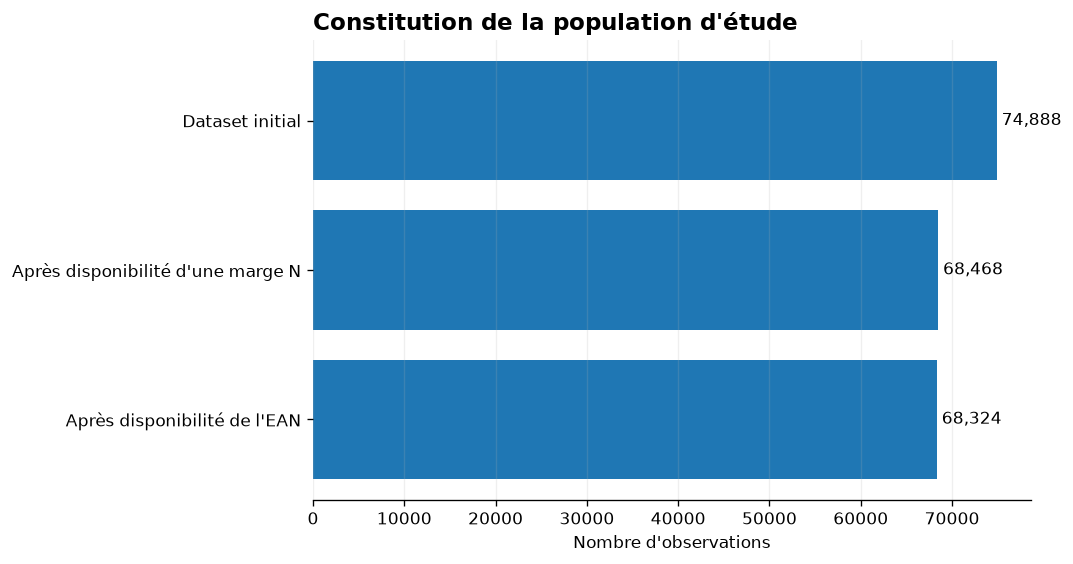

In [13]:
# Visualisation de la constitution de la population

population_flow = pd.DataFrame({
    "Étape": [
        "Dataset initial",
        "Après disponibilité d'une marge N",
        "Après disponibilité de l'EAN",
    ],
    "Observations": [
        population_initiale,
        population_initiale - exclus_sans_marge,
        len(df_business),
    ],
})

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    population_flow["Étape"][::-1],
    population_flow["Observations"][::-1]
)

ax.set_title(
    "Constitution de la population d'étude",
    loc="left",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Nombre d'observations")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.grid(axis="y", visible=False)

for bar, value in zip(bars, population_flow["Observations"][::-1]):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f" {value:,}",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

In [15]:
# Tri chronologique pour préparer les traitements temporels ultérieurs
df_business["_Month_Order"] = (
    df_business["MonthLib"]
    .astype("string")
    .map(month_order)
)

df_business = (
    df_business
    .sort_values(
        by=[
            "Year",
            "_Month_Order",
            "International Department",
            "International Sub Department",
            "International Family",
            "EAN",
        ],
        kind="stable",
    )
    .drop(columns="_Month_Order")
    .reset_index(drop=True)
)

print("Tri chronologique : OK")

Tri chronologique : OK


In [16]:
# Contrôles finaux de structure
assert df_business.columns.tolist() == expected_columns
assert len(df_business) == population_initiale - exclus_sans_marge - exclus_sans_ean
assert df_business["EAN"].notna().all()

final_summary = pd.DataFrame({
    "Indicateur": [
        "Observations initiales",
        "Exclues — aucune marge N",
        "Exclues — EAN manquant",
        "Observations retenues",
        "EAN distincts",
        "Départements distincts",
        "Sous-départements distincts",
        "Familles distinctes",
    ],
    "Valeur": [
        population_initiale,
        exclus_sans_marge,
        exclus_sans_ean,
        len(df_business),
        df_business["EAN"].nunique(),
        df_business["International Department"].nunique(),
        df_business["International Sub Department"].nunique(),
        df_business["International Family"].nunique(),
    ],
})

display(final_summary)

,Indicateur,Valeur
0,Observations initiales,74888
1,Exclues — aucune marge N,6420
2,Exclues — EAN manquant,144
3,Observations retenues,68324
4,EAN distincts,5781
5,Départements distincts,3
6,Sous-départements distincts,3
7,Familles distinctes,19


In [17]:
# Export du dataset 
df_business.to_csv(
    DATASET_BUSINESS,
    index=False,
    encoding="utf-8-sig"
)

print(f"Dataset métier sauvegardé")

Dataset métier sauvegardé


In [18]:
# Export de la synthèse finale
summary_path = PREPROCESSING_DIR / "business_summary.csv"

final_summary.to_csv(
    summary_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"Synthèse sauvegardée ")

Synthèse sauvegardée 


## Conclusion du notebook

Le dataset est désormais :

- homogénéisé au niveau des formats et des types ;
- validé sur sa structure temporelle ;
- restreint aux observations disposant d'une marge N exploitable et d'un EAN ;
- trié chronologiquement ;
- conservé sans suppression des comportements économiques atypiques.

`dataset_business.csv` constitue l'entrée du **Feature Engineering**.